In [1]:
import pandas as pd
import zipfile
import missingno as msno

In [2]:
# Chemin vers ton fichier zip
zip_path = '../data/valeursfoncieres-2025-s1.txt.zip'

df = pd.read_csv(zip_path, sep='|', decimal=",", compression="zip", low_memory=False)

df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,133.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17.0


In [3]:
df.columns   # Noms des colonnes

Index(['Identifiant de document', 'Reference document', '1 Articles CGI',
       '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI',
       'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere',
       'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal',
       'Commune', 'Code departement', 'Code commune', 'Prefixe de section',
       'Section', 'No plan', 'No Volume', '1er lot',
       'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot',
       '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot',
       'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot',
       'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local',
       'Surface reelle bati', 'Nombre pieces principales', 'Nature culture',
       'Nature culture speciale', 'Surface terrain'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387077 entries, 0 to 1387076
Data columns (total 43 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Identifiant de document     0 non-null        float64
 1   Reference document          0 non-null        float64
 2   1 Articles CGI              0 non-null        float64
 3   2 Articles CGI              0 non-null        float64
 4   3 Articles CGI              0 non-null        float64
 5   4 Articles CGI              0 non-null        float64
 6   5 Articles CGI              0 non-null        float64
 7   No disposition              1387077 non-null  int64  
 8   Date mutation               1387077 non-null  object 
 9   Nature mutation             1387077 non-null  object 
 10  Valeur fonciere             1373082 non-null  float64
 11  No voie                     873098 non-null   float64
 12  B/T/Q                       64520 non-null    object 
 1

In [5]:
df.dtypes    # Types de données (int, float, object, etc.)

Identifiant de document       float64
Reference document            float64
1 Articles CGI                float64
2 Articles CGI                float64
3 Articles CGI                float64
4 Articles CGI                float64
5 Articles CGI                float64
No disposition                  int64
Date mutation                  object
Nature mutation                object
Valeur fonciere               float64
No voie                       float64
B/T/Q                          object
Type de voie                   object
Code voie                      object
Voie                           object
Code postal                   float64
Commune                        object
Code departement               object
Code commune                    int64
Prefixe de section            float64
Section                        object
No plan                         int64
No Volume                      object
1er lot                        object
Surface Carrez du 1er lot     float64
2eme lot    

In [6]:
df.shape     # (nombre de lignes, nombre de colonnes)

(1387077, 43)

In [7]:
df.isnull().sum()     # (Compter les valeurs manquantes)

Identifiant de document       1387077
Reference document            1387077
1 Articles CGI                1387077
2 Articles CGI                1387077
3 Articles CGI                1387077
4 Articles CGI                1387077
5 Articles CGI                1387077
No disposition                      0
Date mutation                       0
Nature mutation                     0
Valeur fonciere                 13995
No voie                        513979
B/T/Q                         1322557
Type de voie                   542232
Code voie                       12158
Voie                            12171
Code postal                     12231
Commune                             0
Code departement                    0
Code commune                        0
Prefixe de section            1316580
Section                            56
No plan                             0
No Volume                     1384014
1er lot                        944993
Surface Carrez du 1er lot     1251644
2eme lot    

In [8]:
df.describe()     # Statistiques descriptives (pour les colonnes numériques)

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Valeur fonciere,No voie,...,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Surface terrain
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.387077e+06,1.373082e+06,873098.000000,...,10082.000000,1712.000000,6050.000000,760.000000,1.387077e+06,814739.000000,0.0,813890.000000,813890.000000,9.394530e+05
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.064330e+00,7.034421e+05,635.251208,...,90.496231,169.222897,92.413884,120.075316,4.534882e-01,2.288481,NaN,64.034367,1.707985,3.034890e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.412386e-01,4.944190e+06,1913.561251,...,380.731374,215.209970,367.516762,85.709410,8.618771e-01,0.922436,NaN,635.390947,2.061545,4.940377e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.500000e-01,1.000000,...,2.000000,0.450000,2.000000,1.800000,0.000000e+00,1.000000,NaN,0.000000,0.000000,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,5.935000e+04,8.000000,...,9.000000,40.000000,19.000000,51.300000,0.000000e+00,1.000000,NaN,0.000000,0.000000,2.520000e+02
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.580000e+05,24.000000,...,55.000000,79.530000,97.000000,145.395000,0.000000e+00,3.000000,NaN,28.000000,0.000000,6.390000e+02
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,2.950000e+05,93.000000,...,89.000000,169.620000,97.000000,169.620000,1.000000e+00,3.000000,NaN,80.000000,3.000000,1.905000e+03
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.700000e+01,3.172908e+08,9999.000000,...,20080.000000,3804.200000,20081.000000,799.720000,1.500000e+02,4.000000,NaN,303623.000000,83.000000,4.353772e+07


In [9]:
df.nunique()     # Nombre de valeurs uniques par colonne

Identifiant de document            0
Reference document                 0
1 Articles CGI                     0
2 Articles CGI                     0
3 Articles CGI                     0
4 Articles CGI                     0
5 Articles CGI                     0
No disposition                    43
Date mutation                    173
Nature mutation                    6
Valeur fonciere                71189
No voie                         5784
B/T/Q                             39
Type de voie                     126
Code voie                      13877
Voie                          234661
Code postal                     5857
Commune                        28603
Code departement                  97
Code commune                     900
Prefixe de section               735
Section                          576
No plan                         5703
No Volume                        283
1er lot                         5604
Surface Carrez du 1er lot      13817
2eme lot                        2629
S

In [10]:
df['No disposition'].unique()     # Liste des valeurs uniques pour une colonne

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 27, 35, 37, 39, 41, 43, 31, 52, 89, 97,
       25, 28, 29, 32, 34, 36, 38, 40, 42])

In [11]:
df.duplicated().value_counts()  # Nombre de lignes en double

False    1290210
True       96867
Name: count, dtype: int64

<Axes: >

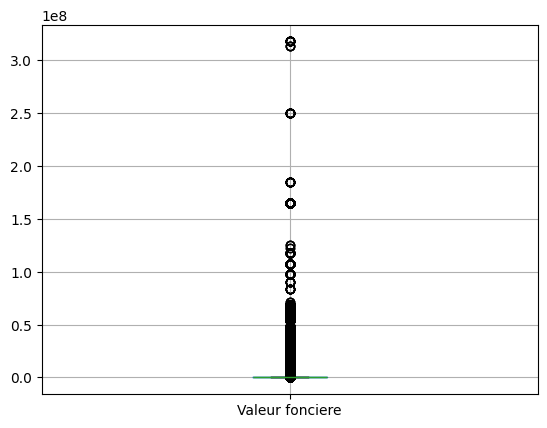

In [12]:
df.boxplot(column='Valeur fonciere')     # Boxplots pour repérer les outliers

<Axes: >

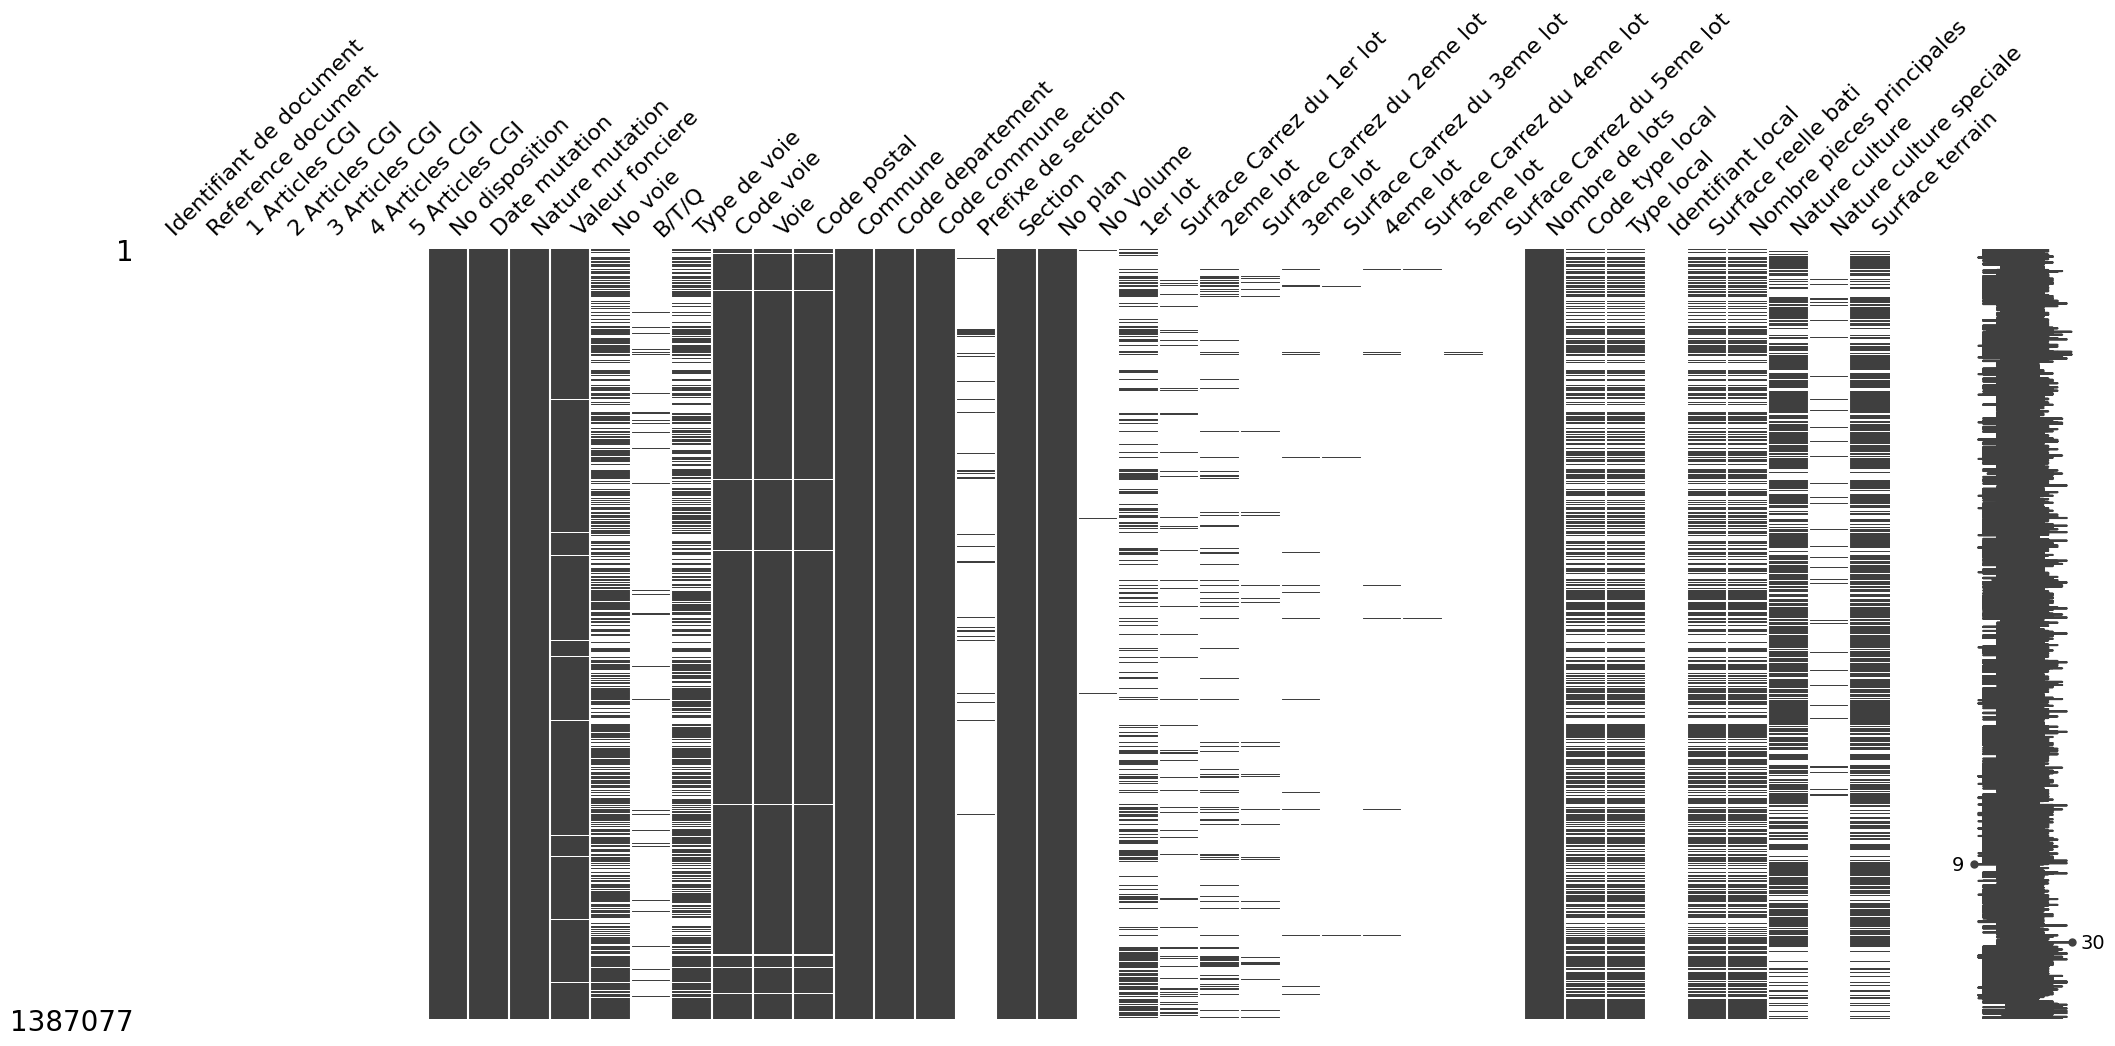

In [13]:
%matplotlib inline
msno.matrix(df)

In [14]:
df['No Volume'].notnull()

0          False
1          False
2          False
3          False
4          False
           ...  
1387072    False
1387073    False
1387074    False
1387075     True
1387076     True
Name: No Volume, Length: 1387077, dtype: bool

# Ajout de la colonne [surface habitable]

In [15]:
df_new = df[['Date mutation', 'Nature mutation', 'Valeur fonciere', 'Code postal', 'Code departement', 'Code commune', 'Surface Carrez du 1er lot', 'Surface Carrez du 2eme lot', 'Surface Carrez du 3eme lot', 'Surface Carrez du 4eme lot', 'Surface Carrez du 5eme lot', 'Nombre pieces principales', 'Surface reelle bati', 'Surface terrain']]
df_new

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Code departement,Code commune,Surface Carrez du 1er lot,Surface Carrez du 2eme lot,Surface Carrez du 3eme lot,Surface Carrez du 4eme lot,Surface Carrez du 5eme lot,Nombre pieces principales,Surface reelle bati,Surface terrain
0,07/01/2025,Vente,468000.0,1550.0,01,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.0
1,07/01/2025,Vente,468000.0,1550.0,01,158,NaN,NaN,NaN,NaN,NaN,5.0,111.0,133.0
2,07/01/2025,Vente,468000.0,1550.0,01,158,NaN,NaN,NaN,NaN,NaN,0.0,0.0,133.0
3,06/01/2025,Vente,180000.0,1200.0,01,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0
4,06/01/2025,Vente,180000.0,1200.0,01,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387072,27/06/2025,Vente,550000.0,75013.0,75,113,NaN,NaN,NaN,NaN,NaN,3.0,61.0,NaN
1387073,27/06/2025,Vente,550386.1,75005.0,75,105,NaN,48.27,NaN,NaN,NaN,2.0,47.0,NaN
1387074,27/06/2025,Vente,550386.1,75005.0,75,105,NaN,48.27,NaN,NaN,NaN,0.0,0.0,NaN
1387075,25/06/2025,Vente,24417580.0,NaN,75,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Suppression des doublons
df_new = df_new.drop_duplicates()

# Remplacement des NaN par 0.00 dans les colonnes avec des valeurs numerique pour le calcul de [Surface habitable]
df_new = df_new.fillna(.0)

In [17]:
df_new.loc[:, "Surface habitable"] = df_new["Surface Carrez du 1er lot"] + df_new["Surface Carrez du 2eme lot"] + df_new["Surface Carrez du 3eme lot"] + df_new["Surface Carrez du 4eme lot"] + df_new["Surface Carrez du 5eme lot"]
df_new

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Code departement,Code commune,Surface Carrez du 1er lot,Surface Carrez du 2eme lot,Surface Carrez du 3eme lot,Surface Carrez du 4eme lot,Surface Carrez du 5eme lot,Nombre pieces principales,Surface reelle bati,Surface terrain,Surface habitable
0,07/01/2025,Vente,468000.0,1550.0,01,158,0.0,0.00,0.0,0.0,0.0,0.0,0.0,78.0,0.00
1,07/01/2025,Vente,468000.0,1550.0,01,158,0.0,0.00,0.0,0.0,0.0,5.0,111.0,133.0,0.00
2,07/01/2025,Vente,468000.0,1550.0,01,158,0.0,0.00,0.0,0.0,0.0,0.0,0.0,133.0,0.00
3,06/01/2025,Vente,180000.0,1200.0,01,257,0.0,0.00,0.0,0.0,0.0,0.0,0.0,46.0,0.00
4,06/01/2025,Vente,180000.0,1200.0,01,257,0.0,0.00,0.0,0.0,0.0,0.0,0.0,17.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387070,27/06/2025,Vente,550000.0,75013.0,75,113,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1387072,27/06/2025,Vente,550000.0,75013.0,75,113,0.0,0.00,0.0,0.0,0.0,3.0,61.0,0.0,0.00
1387073,27/06/2025,Vente,550386.1,75005.0,75,105,0.0,48.27,0.0,0.0,0.0,2.0,47.0,0.0,48.27
1387074,27/06/2025,Vente,550386.1,75005.0,75,105,0.0,48.27,0.0,0.0,0.0,0.0,0.0,0.0,48.27


In [24]:
df_new = df_new[['Valeur fonciere', 'Code postal', 'Code departement', 'Code commune', 'Surface habitable', 'Nombre pieces principales', 'Surface reelle bati', 'Surface terrain']]
df_new

,Valeur fonciere,Code postal,Code departement,Code commune,Surface habitable,Nombre pieces principales,Surface reelle bati,Surface terrain
0,468000.0,1550.0,01,158,0.00,0.0,0.0,78.0
1,468000.0,1550.0,01,158,0.00,5.0,111.0,133.0
2,468000.0,1550.0,01,158,0.00,0.0,0.0,133.0
3,180000.0,1200.0,01,257,0.00,0.0,0.0,46.0
4,180000.0,1200.0,01,257,0.00,0.0,0.0,17.0
...,...,...,...,...,...,...,...,...
1387070,550000.0,75013.0,75,113,0.00,0.0,0.0,0.0
1387072,550000.0,75013.0,75,113,0.00,3.0,61.0,0.0
1387073,550386.1,75005.0,75,105,48.27,2.0,47.0,0.0
1387074,550386.1,75005.0,75,105,48.27,0.0,0.0,0.0


In [25]:
df_new.dtypes

Valeur fonciere              float64
Code postal                  float64
Code departement              object
Code commune                   int64
Surface habitable            float64
Nombre pieces principales    float64
Surface reelle bati          float64
Surface terrain              float64
dtype: object

In [23]:
df_new['Nature mutation'].value_counts()

Nature mutation
Vente                                 1165483
Vente en l'état futur d'achèvement      25752
Echange                                 15443
Vente terrain à bâtir                    2716
Adjudication                              783
Expropriation                             239
Name: count, dtype: int64